In [1]:
# ============================================================
# SECTION 1: INSTALLATION
# ============================================================
# md("## 1. Installation & Environment Setup")

!pip install -q kagglehub scikit-learn xgboost lightgbm catboost
!pip install -q transformers torch datasets
!pip install -q shap lime
# !pip install -q nltk matplotlib seaborn wordcloud
# !pip install -q scipy statsmodels

import warnings
warnings.filterwarnings('ignore')
print("✅ All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All packages installed successfully.


In [2]:
# ============================================================
# SECTION 2: IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import time
import sys
import pickle
import json
from collections import Counter

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Boosting models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Transformers
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer, TrainingArguments,
    pipeline as hf_pipeline
)
from datasets import Dataset as HFDataset

# Explainability
import shap
import lime
from lime.lime_text import LimeTextExplainer

# Stats
from scipy.stats import chi2_contingency, wilcoxon
from statsmodels.stats.contingency_tables import mcnemar

# Plotting style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

LABEL_MAP = {0: 'FAKE', 1: 'REAL'}
print("✅ All imports successful.")
print(f"   PyTorch: {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")

✅ All imports successful.
   PyTorch: 2.11.0+cu128  |  CUDA available: True


In [ ]:
# ============================================================
# SECTION 3: DATASET LOADING (UPDATED WITH ORIGINAL DATASETS)
# ============================================================
import os
import json
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# ── 1. Load PubHealth Dataset (Kaggle) ───────────────────────────────────────
print("Loading PubHealth dataset...")
df_pubhealth_train = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ersindemirel/pubhealthdataset",
    "train.tsv"
)
df_pubhealth_test = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ersindemirel/pubhealthdataset",
    "test.tsv"
)
df_pubhealth = pd.concat([df_pubhealth_train, df_pubhealth_test], ignore_index=True)
print(f"  PubHealth loaded: {df_pubhealth.shape[0]:,} rows, {df_pubhealth.shape[1]} columns")
df_pubhealth.to_csv('pubhealth.csv', index=False)

# ── 2. Load Original CoAID Dataset ──────────────────────────────────────────
print("\nCloning and loading CoAID ")
if not os.path.exists("CoAID"):
    !git clone https://github.com/cuilimeng/CoAID.git

coaid_dfs = []
coaid_path = "CoAID/05-01-2020"  # Loading the primary baseline release directory

if os.path.exists(coaid_path):
    fake_path = os.path.join(coaid_path, "NewsFakeCOVID-19.csv")
    real_path = os.path.join(coaid_path, "NewsRealCOVID-19.csv")

    if os.path.exists(fake_path):
        df_c_fake = pd.read_csv(fake_path)
        df_c_fake['label'] = 'false'  # Matching PubHealth label convention
        coaid_dfs.append(df_c_fake)

    if os.path.exists(real_path):
        df_c_real = pd.read_csv(real_path)
        df_c_real['label'] = 'true'
        coaid_dfs.append(df_c_real)

if coaid_dfs:
    df_coaid = pd.concat(coaid_dfs, ignore_index=True)
    # Rename features to align with the notebook's downstream pipeline requirements
    df_coaid = df_coaid.rename(columns={'title': 'claim', 'abstract': 'main_text'})
    df_coaid['subjects'] = 'covid-19'
    df_coaid.to_csv('coaid.csv', index=False)
    print(f"  Original CoAID loaded: {df_coaid.shape[0]:,} rows")
else:
    print("  ❌ Failed to load CoAID original data.")


# ── 3. Load Original FakeHealth Dataset ──────────────────────────────────────
print("\nCloning and loading FakeHealth ")
if not os.path.exists("FakeHealth"):
    !git clone https://github.com/EnyanDai/FakeHealth.git

fakehealth_path = "FakeHealth/dataset/reviews"
fakehealth_records = []

if os.path.exists(fakehealth_path):
    # Aggregating both HealthStory and HealthRelease review sources
    for filename in ["HealthStory.json", "HealthRelease.json"]:
        file_p = os.path.join(fakehealth_path, filename)
        if os.path.exists(file_p):
            with open(file_p, 'r') as f:
                data = json.load(f)
                for item in data:
                    # FakeHealth tracks structural quality metrics.
                    # A rating review score below 3 out of 5 generally flags low-veracity content.
                    lbl = 'false' if item.get('rating', 5) < 3 else 'true'
                    fakehealth_records.append({
                        'claim': item.get('title', ''),
                        'main_text': item.get('description', '') or item.get('summary', ''),
                        'label': lbl,
                        'subjects': 'health_news'
                    })

if fakehealth_records:
    df_fakehealth = pd.DataFrame(fakehealth_records)
    df_fakehealth.to_csv('fakehealth.csv', index=False)
    print(f"  Original FakeHealth loaded: {df_fakehealth.shape[0]:,} rows")
else:
    print("  ❌ Failed to load FakeHealth original data.")

Loading PubHealth dataset...


100%|██████████| 19.2M/19.2M [00:00<00:00, 48.2MB/s]

Extracting zip of train.tsv...


100%|██████████| 2.43M/2.43M [00:00<00:00, 116MB/s]

Extracting zip of test.tsv...


  PubHealth loaded: 11,067 rows, 10 columns

Cloning and loading CoAID 
Cloning into 'CoAID'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 83 (delta 23), reused 46 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 3.97 MiB | 8.83 MiB/s, done.
Resolving deltas: 100% (23/23), done.
  Original CoAID loaded: 2,162 rows

Cloning and loading FakeHealth 
Cloning into 'FakeHealth'...
remote: Enumerating objects: 2292, done.
remote: Counting objects: 100% (2292/2292), done.
remote: Compressing objects: 100% (2211/2211), done.
remote: Total 2292 (delta 79), reused 2292 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (2292/2292), 15.38 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (79/79), done.
  Original FakeHealth loaded: 2,296 rows


In [5]:
df_pubhealth.head()

,claim_id,claim,date_published,explanation,fact_checkers,main_text,sources,label,subjects,Unnamed: 0
0,15661,"""The money the Clinton Foundation took from fr...","April 26, 2015","""Gingrich said the Clinton Foundation """"took m...",Katie Sanders,"""Hillary Clinton is in the political crosshair...",https://www.wsj.com/articles/clinton-foundatio...,false,"Foreign Policy, PunditFact, Newt Gingrich,",NaN
1,9893,Annual Mammograms May Have More False-Positives,"October 18, 2011",This article reports on the results of a study...,,While the financial costs of screening mammogr...,,mixture,"Screening,WebMD,women's health",NaN
2,11358,SBRT Offers Prostate Cancer Patients High Canc...,"September 28, 2016",This news release describes five-year outcomes...,"Mary Chris Jaklevic,Steven J. Atlas, MD, MPH,K...",The news release quotes lead researcher Robert...,https://www.healthnewsreview.org/wp-content/up...,mixture,"Association/Society news release,Cancer",NaN
3,10166,"Study: Vaccine for Breast, Ovarian Cancer Has ...","November 8, 2011","While the story does many things well, the ove...",,"The story does discuss costs, but the framing ...",http://clinicaltrials.gov/ct2/results?term=can...,true,"Cancer,WebMD,women's health",NaN
4,11276,Some appendicitis cases may not require ’emerg...,"September 20, 2010",We really don’t understand why only a handful ...,,"""Although the story didn’t cite the cost of ap...",,true,,NaN


In [6]:
df_fakehealth.head()

,claim,main_text,label,subjects
0,Guardian jumps to conclusions about an Alzheim...,The story’s headline states: “Virtual reality ...,false,health_news
1,"In story on experimental contraceptive gel, Re...",This leaves both investors and lay audiences w...,true,health_news
2,"Using a single patient anecdote, ABC News hail...",Breakthrough? Based on the story of one patien...,false,health_news
3,Hard to find the journalism in this brief Reut...,The story mostly just rehashes a drug company ...,false,health_news
4,A little more context would have boosted alrea...,Did the study findings really earn a label of ...,true,health_news


In [7]:
df_coaid.head()

,Unnamed: 0,type,fact_check_url,archive,news_url,news_url2,news_url3,news_url4,news_url5,claim,newstitle,content,main_text,publish_date,meta_keywords,label,subjects
0,0,post,https://factcheck.afp.com/false-advice-refusin...,https://perma.cc/J4N6-39D5,https://www.facebook.com/photo.php?fbid=551960...,NaN,NaN,NaN,NaN,Facebook posts shared in at least three countr...,NaN,NaN,NaN,NaN,NaN,false,covid-19
1,1,article,https://www.politifact.com/factchecks/2020/apr...,NaN,http://legis.wisconsin.gov/assembly/republican...,NaN,NaN,NaN,NaN,Wisconsin is Òclearly seeing a decline in COVI...,"""Wisconsin Legislature Takes Gov. Evers to Court""",speaker robin vos r rochester and senate major...,NaN,NaN,"""""",false,covid-19
2,2,post,https://factcheck.afp.com/posts-claim-children...,https://perma.cc/V4HX-M2XJ,https://www.facebook.com/iAmJessenia/photos/a....,NaN,NaN,NaN,NaN,Facebook posts claim a child who is infected w...,NaN,NaN,NaN,NaN,NaN,false,covid-19
3,3,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/kokernagnews/photos/a...,NaN,NaN,NaN,NaN,IndiaÕs Ministry of Home Affairs banning citiz...,NaN,NaN,NaN,NaN,NaN,false,covid-19
4,5,post,https://checkyourfact.com/2020/04/20/fact-chec...,NaN,https://www.facebook.com/photo.php?fbid=102193...,NaN,NaN,NaN,NaN,"42 Democratic senators, plus two Independents,...",NaN,NaN,NaN,NaN,NaN,false,covid-19


In [4]:
# ============================================================
# SECTION 4: LABEL STANDARDIZATION
# ============================================================
import pandas as pd

# Map labels to binary (1 = REAL, 0 = FAKE)
# Notice: 'unproven' and 'snopes' are omitted from this list.
# The function will automatically drop rows containing those labels.
LABEL_NORMALIZE = {
    'true': 1,
    'mostly true': 1,
    'mostly-true': 1,
    'half-true': 0,
    'barely-true': 0,
    'mixture': 0,
    'mostly false': 0,
    'mostly-false': 0,
    'false': 0,
    'pants-fire': 0
}
def standardize_dataset(df, text_cols=('claim', 'main_text'), label_col='label', drop_cols=None, dataset_name='dataset'):
    df = df.copy()

    # 1. Convert text and label columns to string types upfront
    # This prevents unhashable dict errors and ensures downstream string operations work perfectly.
    for col in list(text_cols) + [label_col]:
        if col in df.columns:
            df[col] = df[col].astype(str)

    # 2. Safe duplicate removal using a subset of hashable columns
    subset_cols = [c for c in list(text_cols) + [label_col] if c in df.columns]
    df = df.drop_duplicates(subset=subset_cols)

    # 3. Drop unnecessary columns
    if drop_cols:
        df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    # 4. Drop rows with missing labels
    df = df.dropna(subset=[label_col])

    # 5. Standardize labels
    df['label_raw'] = df[label_col].str.strip().str.lower()
    df = df[df['label_raw'].isin(LABEL_NORMALIZE.keys())].copy()
    df['label_binary'] = df['label_raw'].map(LABEL_NORMALIZE)

    # 6. Combine Claim and Main Text
    texts = []
    for col in text_cols:
        if col in df.columns:
            texts.append(df[col].fillna(''))

    if texts:
        df['combined_text'] = texts[0]
        for t in texts[1:]:
            df['combined_text'] = df['combined_text'] + " " + t
    df['combined_text'] = df['combined_text'].astype(str)

    # Track dataset source for downstream EDA
    df['dataset_name'] = dataset_name

    print(f"  [{dataset_name}] {len(df):,} rows  |  REAL: {df['label_binary'].sum():,}  |  FAKE: {(df['label_binary']==0).sum():,}")
    return df

# We drop 'subjects' from this list so we can keep it for your Topic-Aware EDA later
PUBHEALTH_DROP = ['claim_id', 'date_published', 'explanation', 'fact_checkers', 'sources']
FAKEHEALTH_DROP = ['claim_id', 'date_published', 'explanation', 'fact_checkers', 'sources']
COAID_DROP = ['type', 'fact_check_url', 'archive', 'news_url', 'news_url2', 'news_url3', 'news_url4', 'news_url5', 'publish_date', 'meta_keywords']


print("Standardizing datasets...")
df_pub = standardize_dataset(df_pubhealth, drop_cols=PUBHEALTH_DROP, dataset_name='PubHealth')
df_fh  = standardize_dataset(df_fakehealth, drop_cols=FAKEHEALTH_DROP, dataset_name='FakeHealth')
df_co  = standardize_dataset(df_coaid, drop_cols=COAID_DROP, dataset_name='CoAID')

# Bundle them into a dictionary for easy iteration in the next sections
DATASETS = {
    'PubHealth': df_pub,
    'FakeHealth': df_fh,
    'CoAID': df_co
}
print("\n✅ All datasets standardized.")

Standardizing datasets...
  [PubHealth] 10,701 rows  |  REAL: 5,677  |  FAKE: 5,024
  [FakeHealth] 2,296 rows  |  REAL: 1,533  |  FAKE: 763
  [CoAID] 2,133 rows  |  REAL: 1,569  |  FAKE: 564

✅ All datasets standardized.


In [8]:
# df_co.head()
df_fakehealth.head()

df_fh.head()
# df_pub.head()

,claim,main_text,label,subjects,label_raw,label_binary,combined_text,dataset_name
0,Guardian jumps to conclusions about an Alzheim...,The story’s headline states: “Virtual reality ...,false,health_news,false,0,Guardian jumps to conclusions about an Alzheim...,FakeHealth
1,"In story on experimental contraceptive gel, Re...",This leaves both investors and lay audiences w...,true,health_news,true,1,"In story on experimental contraceptive gel, Re...",FakeHealth
2,"Using a single patient anecdote, ABC News hail...",Breakthrough? Based on the story of one patien...,false,health_news,false,0,"Using a single patient anecdote, ABC News hail...",FakeHealth
3,Hard to find the journalism in this brief Reut...,The story mostly just rehashes a drug company ...,false,health_news,false,0,Hard to find the journalism in this brief Reut...,FakeHealth
4,A little more context would have boosted alrea...,Did the study findings really earn a label of ...,true,health_news,true,1,A little more context would have boosted alrea...,FakeHealth


In [9]:
df_co.head()

,Unnamed: 0,claim,newstitle,content,main_text,label,subjects,label_raw,label_binary,combined_text,dataset_name
0,0,Facebook posts shared in at least three countr...,NaN,NaN,nan,false,covid-19,false,0,Facebook posts shared in at least three countr...,CoAID
1,1,Wisconsin is Òclearly seeing a decline in COVI...,"""Wisconsin Legislature Takes Gov. Evers to Court""",speaker robin vos r rochester and senate major...,nan,false,covid-19,false,0,Wisconsin is Òclearly seeing a decline in COVI...,CoAID
2,2,Facebook posts claim a child who is infected w...,NaN,NaN,nan,false,covid-19,false,0,Facebook posts claim a child who is infected w...,CoAID
3,3,IndiaÕs Ministry of Home Affairs banning citiz...,NaN,NaN,nan,false,covid-19,false,0,IndiaÕs Ministry of Home Affairs banning citiz...,CoAID
4,5,"42 Democratic senators, plus two Independents,...",NaN,NaN,nan,false,covid-19,false,0,"42 Democratic senators, plus two Independents,...",CoAID


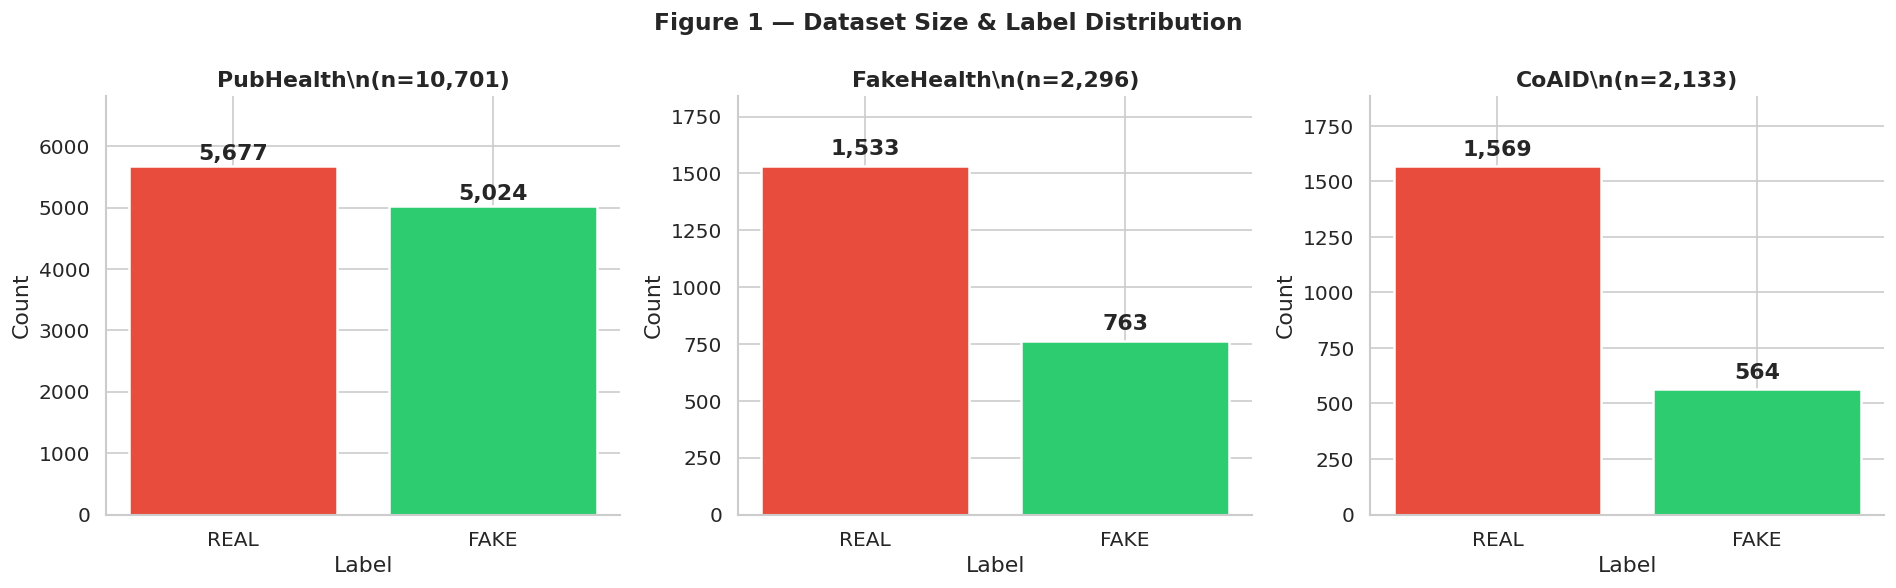

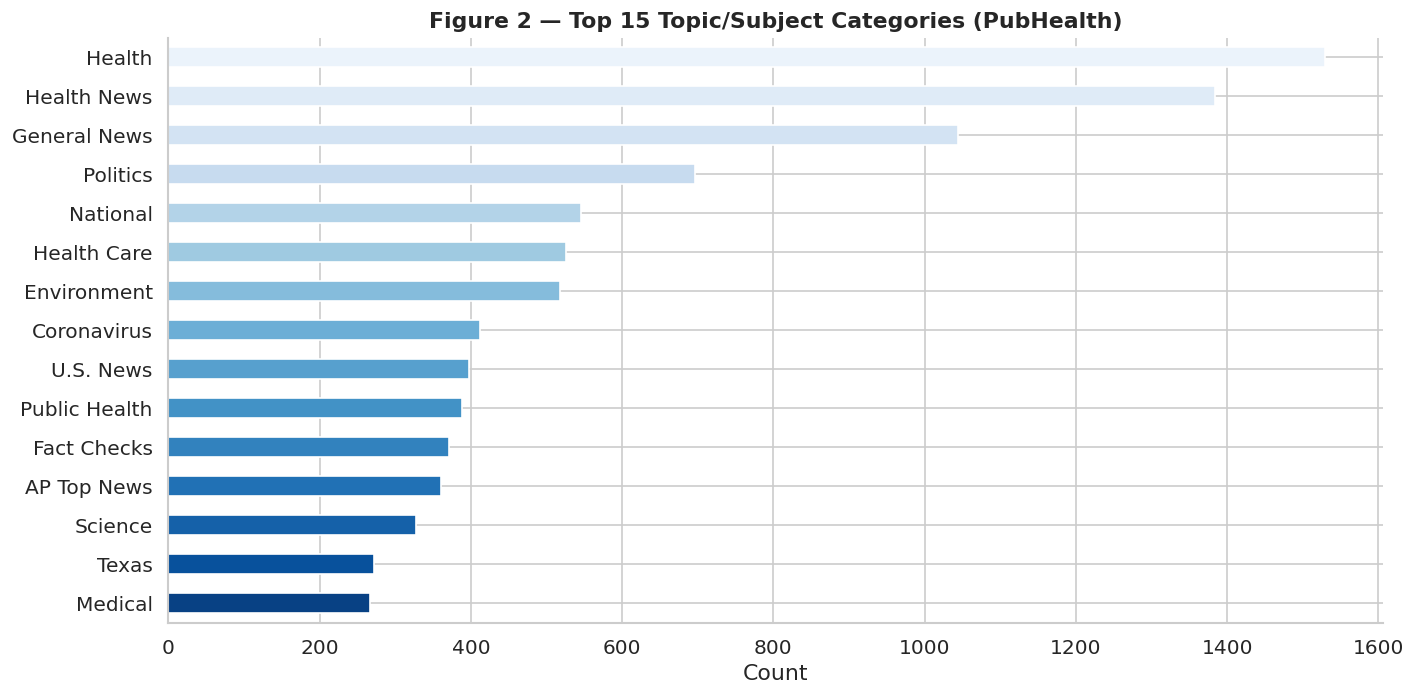

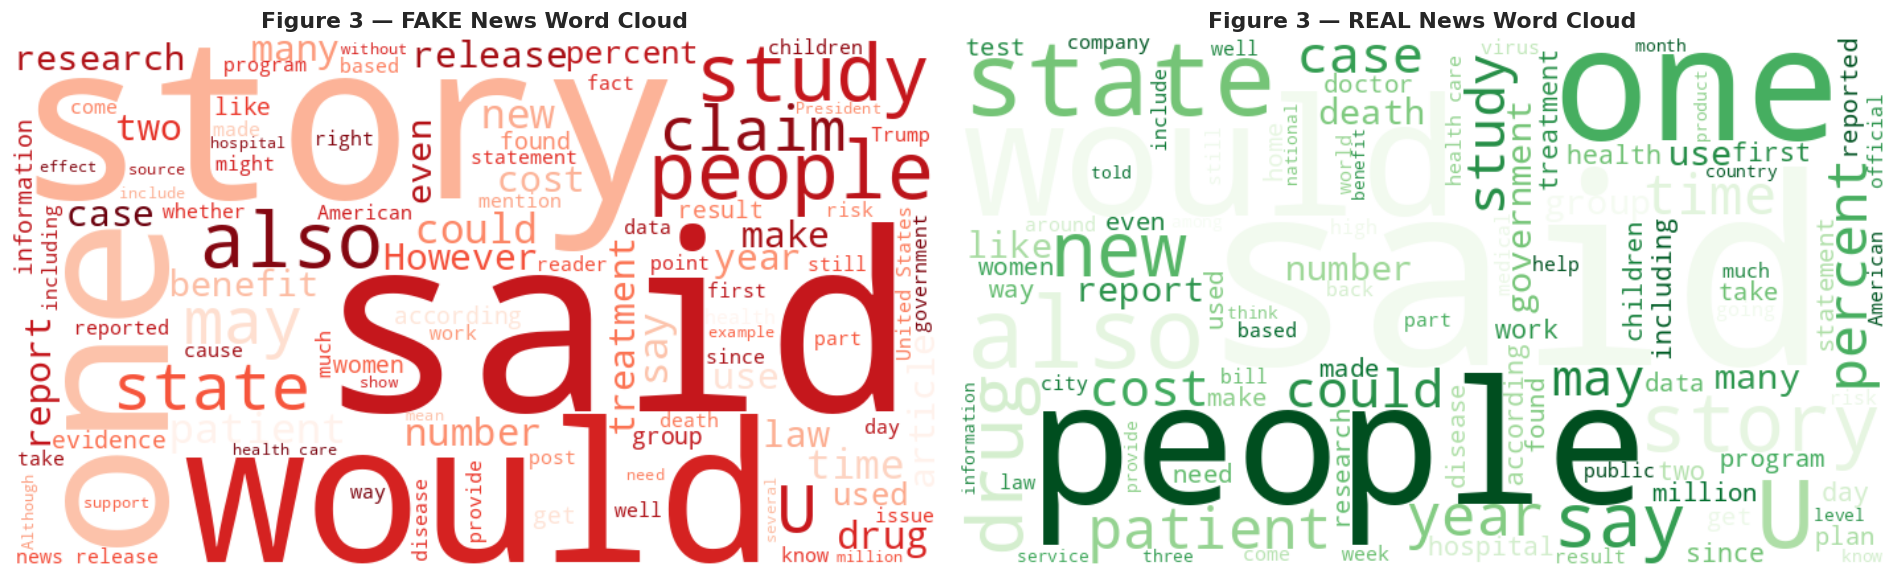

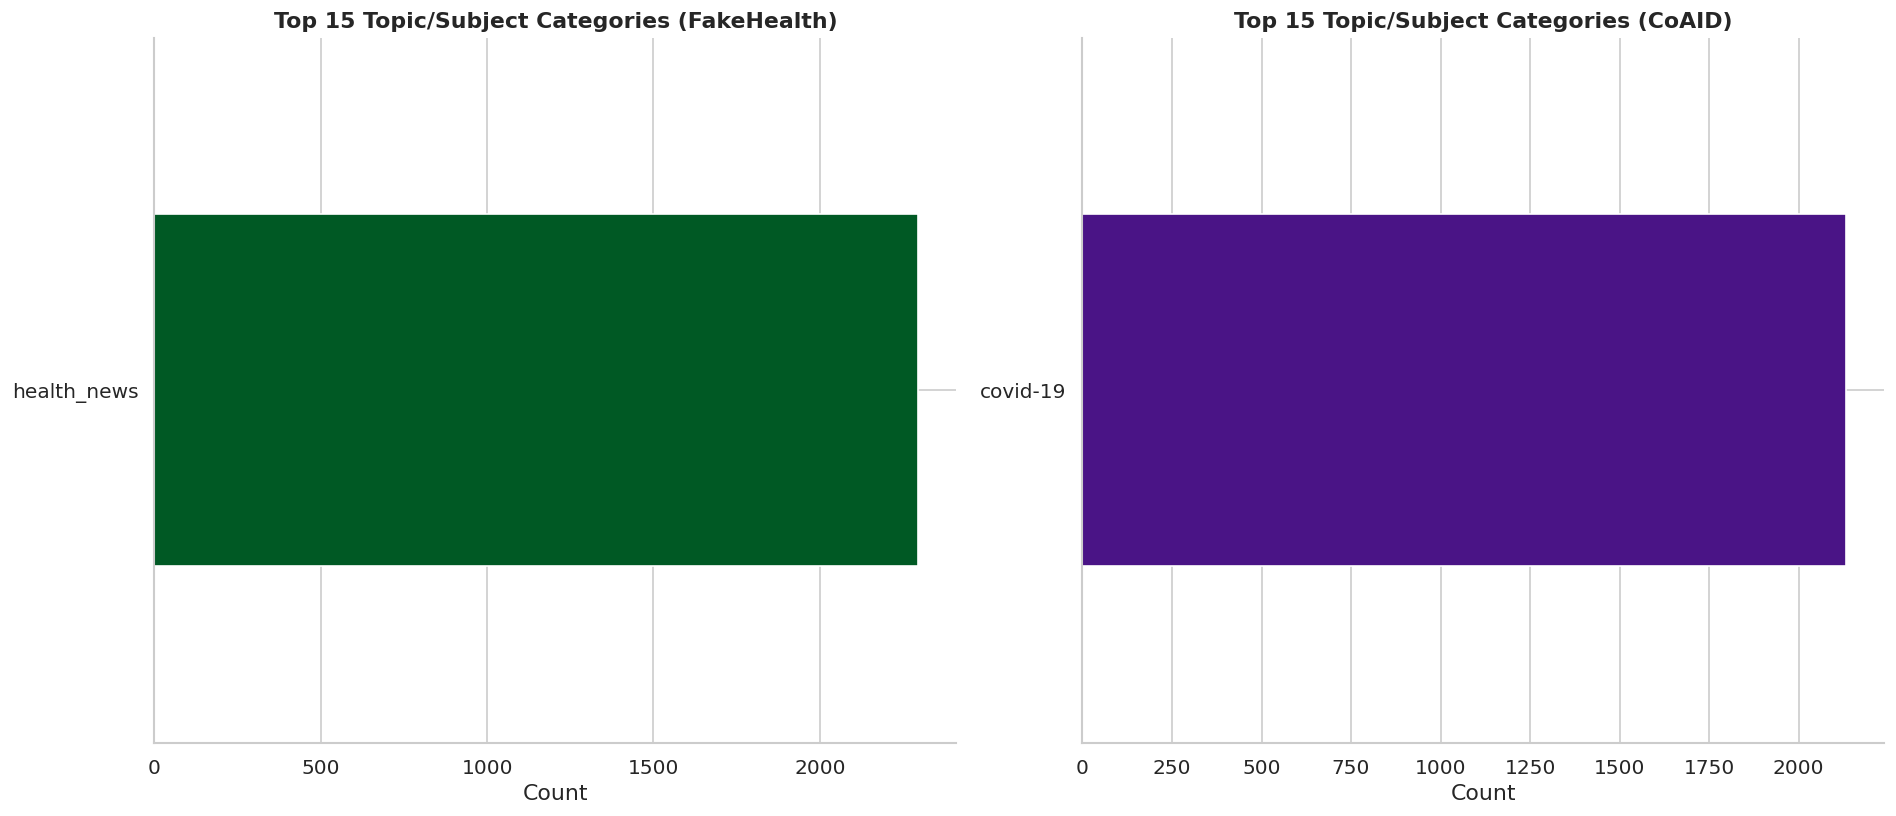

In [ ]:
# ============================================================
# SECTION 5: EDA
# ============================================================
## 5. Exploratory Data Analysis (EDA)")

# ── Figure 1: Dataset Size & Label Distribution ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1 — Dataset Size & Label Distribution', fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, DATASETS.items()):
    counts = df['label_binary'].value_counts().rename({0: 'FAKE', 1: 'REAL'})
    bars = ax.bar(counts.index, counts.values, color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'{name}\\n(n={len(df):,})', fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('fig1_dataset_distribution.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Topic Distribution in PubHealth ────────────────────────────────
subject_series = df_pub['subjects'].apply(
    lambda x: [s.strip() for s in str(x).split(',') if s.strip() and s.strip() != 'Unknown']
)
all_subjects = [s for sublist in subject_series for s in sublist]
top_subjects = pd.Series(all_subjects).value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_subjects.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('Blues_r', 15))
ax.set_title('Figure 2 — Top 15 Topic/Subject Categories (PubHealth)', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.savefig('fig2_topic_distribution.png', bbox_inches='tight')
plt.show()




# ── Figure 3: Word Cloud (FAKE vs REAL) ──────────────────────────────────────
fake_text = ' '.join(df_pub[df_pub['label_binary'] == 0]['combined_text'].sample(500, random_state=42))
real_text = ' '.join(df_pub[df_pub['label_binary'] == 1]['combined_text'].sample(500, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (title, text, cmap) in zip(axes, [
    ('FAKE News Word Cloud', fake_text, 'Reds'),
    ('REAL News Word Cloud', real_text, 'Greens')
]):
    wc = WordCloud(width=700, height=400, background_color='white', colormap=cmap,
                   max_words=100, stopwords=set(stopwords.words('english'))).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Figure 3 — {title}', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig3_wordclouds.png', bbox_inches='tight')
plt.show()
















# ============================================================
# SECTION 5: EDA - TOPIC & VERACITY DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_subjects(df, dataset_name, ax, color_palette='Blues_r'):
    # 1. Split the subjects column by comma and flatten the list
    subject_series = df['subjects'].apply(
        lambda x: [s.strip() for s in str(x).split(',') if s.strip() and s.strip() != 'Unknown']
    )
    all_subjects = [s for sublist in subject_series for s in sublist]

    # 2. Get the top 15 categories
    top_subjects = pd.Series(all_subjects).value_counts().head(15)

    # 3. Plot
    top_subjects.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette(color_palette, 15))
    ax.set_title(f'Top 15 Topic/Subject Categories ({dataset_name})', fontweight='bold')
    ax.set_xlabel('Count')

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot FakeHealth
plot_top_subjects(DATASETS['FakeHealth'], 'FakeHealth', axes[0], 'Greens_r')

# Plot CoAID
plot_top_subjects(DATASETS['CoAID'], 'CoAID', axes[1], 'Purples_r')

plt.tight_layout()
plt.savefig('fig_topic_distribution_multi.png', bbox_inches='tight')
plt.show()



In [12]:
# Print a quick text summary
print("📊 PubHealth Class Balance:")
print(DATASETS['PubHealth']['label_binary'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("📊 FakeHealth Class Balance:")
print(DATASETS['FakeHealth']['label_binary'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n📊 CoAID Class Balance:")
print(DATASETS['CoAID']['label_binary'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

📊 PubHealth Class Balance:
label_binary
1    53.1%
0    46.9%
Name: proportion, dtype: object
📊 FakeHealth Class Balance:
label_binary
1    66.8%
0    33.2%
Name: proportion, dtype: object

📊 CoAID Class Balance:
label_binary
1    73.6%
0    26.4%
Name: proportion, dtype: object


In [13]:
# ============================================================
# SECTION 6: TEXT PREPROCESSING
# ============================================================
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_classical(text: str) -> str:
    """Full cleaning pipeline for Classical Models (SVM, XGBoost, Naive Bayes)."""
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)              # Remove URLs
    text = re.sub(r'[^a-z0-9\s]', '', text)                        # Keep alphanumeric only
    text = re.sub(r'\s+', ' ', text).strip()                       # Collapse whitespace

    # Remove stopwords & lemmatize in one efficient list comprehension
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

def preprocess_distilbert(text: str) -> str:
    """Minimal cleaning for DistilBERT (preserves case, stopwords, and punctuation)."""
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)              # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip()                       # Collapse whitespace
    return text[:512]                                              # Hard cap for sanity

# Apply preprocessing functions to all 3 datasets via the DATASETS dictionary
for name, df in DATASETS.items():
    print(f"Preprocessing {name}...", end=' ')

    # Create distinct columns for the different model architectures
    df['text_classical'] = df['combined_text'].apply(preprocess_classical)
    df['text_bert'] = df['combined_text'].apply(preprocess_distilbert)

    print(f"✅ ({len(df):,} rows)")

print("\n✅ Text Preprocessing complete for both Classical and BERT models.")

Preprocessing PubHealth... ✅ (10,701 rows)
Preprocessing FakeHealth... ✅ (2,296 rows)
Preprocessing CoAID... ✅ (2,133 rows)

✅ Text Preprocessing complete for both Classical and BERT models.


In [14]:
# # ============================================================
# # SECTION 7: TRAIN/TEST SPLITS
# # ============================================================
# Train / Test Split (per Dataset)")

def make_splits(df, text_col='text_classical', label_col='label_binary', test_size=0.2):
    # \"\"\"Stratified split preserving class balance.\"\"\"
    X = df[text_col].values
    y = df[label_col].values
    return train_test_split(X, y, test_size=test_size, random_state=RANDOM_SEED, stratify=y)

# Within-dataset splits (used for within-dataset evaluation)
SPLITS = {}
for name, df in DATASETS.items():
    X_tr, X_te, y_tr, y_te = make_splits(df)
    SPLITS[name] = {
        'X_train': X_tr, 'X_test': X_te,
        'y_train': y_tr, 'y_test': y_te
    }
    print(f"{name}: train={len(X_tr):,}  test={len(X_te):,}")

# Also store full arrays for cross-dataset evaluation
FULL_SPLITS = {}
for name, df in DATASETS.items():
    FULL_SPLITS[name] = {
        'X': df['text_classical'].values,
        'y': df['label_binary'].values,
        'subjects': df['subjects'].values,
        'X_bert': df['text_bert'].values
    }

PubHealth: train=8,560  test=2,141
FakeHealth: train=1,836  test=460
CoAID: train=1,706  test=427


In [ ]:
# ============================================================
# SECTION 8: TF-IDF VECTORIZATION
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

# ── 1. Initialize the Vectorizer ─────────────────────────────────────────────
# We use a shared TF-IDF vocabulary fitted ONLY on PubHealth train data.
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    max_features=20000,
    min_df=2,
    max_df=0.98,
    strip_accents='unicode'
)

# ── 2. Fit on PubHealth ONLY ─────────────────────────────────────────────────
print("Fitting TF-IDF Vectorizer strictly on PubHealth training data...")
tfidf.fit(SPLITS['PubHealth']['X_train'])
print(f"✅ TF-IDF vocabulary size: {len(tfidf.vocabulary_):,} features")

# ── 3. Transform ALL Datasets ────────────────────────────────────────────────
TFIDF_SPLITS = {}

print("\nVectorizing all 3 datasets using the shared vocabulary...")
for name in DATASETS.keys():
    print(f"  ⏳ Transforming {name}...")

    TFIDF_SPLITS[name] = {

        'X_train': tfidf.transform(SPLITS[name]['X_train']),
        'X_test':  tfidf.transform(SPLITS[name]['X_test']),
        'y_train':       SPLITS[name]['y_train'],
        'y_test':        SPLITS[name]['y_test'],

        # Transform the FULL dataset for cross-dataset evaluation later
        # 'X_full_tfidf':  tfidf.transform(FULL_SPLITS[name]['X']),
        'X_full':  tfidf.transform(FULL_SPLITS[name]['X']),
        'y_full':        FULL_SPLITS[name]['y']
    }

print("\n✅ SECTION 8 COMPLETE: All datasets are vectorized and ready for training!")

Fitting TF-IDF Vectorizer strictly on PubHealth training data...
✅ TF-IDF vocabulary size: 20,000 features

Vectorizing all 3 datasets using the shared vocabulary...
  ⏳ Transforming PubHealth...
  ⏳ Transforming FakeHealth...
  ⏳ Transforming CoAID...

✅ SECTION 8 COMPLETE: All datasets are vectorized and ready for training!


In [23]:
# ============================================================
# SECTION 9: MODEL TRAINING & EVALUATION (ALL DATASETS)  v2
# ============================================================
import time
import sys
import pickle
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# ── Define models ─────────────────────────────────────────────────────────────
def build_models():
    return {
        'Naive Bayes': ComplementNB(alpha=0.1),
        'Logistic Regression': LogisticRegression(
            C=1.0, max_iter=1000, solver='saga', n_jobs=-1, random_state=RANDOM_SEED
        ),
        'SVM': CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_SEED), cv=3
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=RANDOM_SEED, n_jobs=-1
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=63,
            random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
        ),
        'CatBoost': CatBoostClassifier(
            iterations=200, learning_rate=0.05, depth=6,
            random_seed=RANDOM_SEED, verbose=0, task_type='CPU'
        )
}


# Master structures to hold all artifacts
TRAINED_MODELS = {}
ALL_RESULTS = []

for ds_name, splits in TFIDF_SPLITS.items():
    print(f"\n{'='*80}")
    print(f"🚀 TRAINING & EVALUATING MODELS ON: {ds_name.upper()}")
    print(f"{'='*80}")

    # Extract matrices
    # X_train = splits['X_train_tfidf']
    # y_train = splits['y_train']
    # X_test  = splits['X_test_tfidf']
    # y_test  = splits['y_test']
    # Extract matrices
    X_train = splits['X_train']  # Changed from 'X_train_tfidf'
    y_train = splits['y_train']
    X_test  = splits['X_test']   # Changed from 'X_test_tfidf'
    y_test  = splits['y_test']

    # Initialize fresh models for the current dataset
    models = build_models()
    TRAINED_MODELS[ds_name] = {}

    ds_results = [] # Temporary list for the current dataset's display table

    for model_name, model in models.items():
        # 1. Train Model & Track Time
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        # 2. Inference & Track Time
        t1 = time.time()
        y_pred = model.predict(X_test)
        infer_time = time.time() - t1

        # 3. Probabilities for ROC-AUC (Replicating your previous logic)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            # Min-Max scaling to prevent negative probability errors
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            y_prob = y_pred # Fallback

        roc_auc = roc_auc_score(y_test, y_prob)

        # 4. Model Size Calculation
        model_size_kb = sys.getsizeof(pickle.dumps(model)) / 1024

        # 5. Core Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        # Store model
        TRAINED_MODELS[ds_name][model_name] = model

        # Build Result Row
        row = {
            'Dataset': ds_name,
            'Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC-AUC': roc_auc,
            'Train Time (s)': train_time,
            'Infer Time (s)': infer_time,
            'Model Size (KB)': model_size_kb
        }
        ds_results.append(row)
        ALL_RESULTS.append(row)

    # ── COLORFUL DISPLAY PER DATASET ───────────────────────────────────────
    # Convert results to DataFrame and set the Model name as the index
    df_ds = pd.DataFrame(ds_results).drop(columns=['Dataset'])
    df_ds.set_index('Model', inplace=True)

    # Apply Pandas Styler:
    # - Greens/Blues for Performance Metrics (Higher is better)
    # - Reds/Oranges for Time & Size Metrics (Lower is better)
    styled_ds = df_ds.style.background_gradient(cmap='viridis', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']) \
                           .background_gradient(cmap='OrRd', subset=['Train Time (s)', 'Infer Time (s)', 'Model Size (KB)']) \
                           .format("{:.4f}", subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']) \
                           .format("{:.4f}", subset=['Train Time (s)', 'Infer Time (s)']) \
                           .format("{:.1f}", subset=['Model Size (KB)']) \
                           .set_caption(f"<b>Performance Metrics: {ds_name}</b>")

    display(styled_ds)

# ── FINAL CONSOLIDATED CROSS-DATASET F1 PIVOT ────────────────────────────────
print("\n" + "="*80)
print("📊 FINAL OVERVIEW: F1-SCORES ACROSS ALL DATASETS")
print("="*80)

df_all = pd.DataFrame(ALL_RESULTS)
f1_pivot = df_all.pivot(index='Model', columns='Dataset', values='F1 Score')

styled_pivot = f1_pivot.style.background_gradient(cmap='plasma') \
                             .format("{:.4f}") \
                             .set_caption("<b>F1-Score Comparison</b>")
display(styled_pivot)


🚀 TRAINING & EVALUATING MODELS ON: PUBHEALTH


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s),Infer Time (s),Model Size (KB)
Model,,,,,,,,
Naive Bayes,0.7973,0.8718,0.7245,0.7913,0.8642,0.0733,0.0167,781.9
Logistic Regression,0.8384,0.8712,0.8160,0.8427,0.9122,1.9428,0.0021,157.0
SVM,0.8431,0.8610,0.8398,0.8503,0.9187,1.2225,0.0235,470.4
XGBoost,0.8431,0.8745,0.8222,0.8475,0.9182,168.4490,0.0551,472.6
LightGBM,0.8407,0.8711,0.8213,0.8455,0.9197,124.7302,0.0694,2086.1
CatBoost,0.8333,0.8551,0.8257,0.8401,0.9070,296.8054,0.0795,1068.0



🚀 TRAINING & EVALUATING MODELS ON: FAKEHEALTH


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s),Infer Time (s),Model Size (KB)
Model,,,,,,,,
Naive Bayes,0.7283,0.7585,0.8697,0.8103,0.7694,0.0036,0.0008,781.9
Logistic Regression,0.7152,0.7200,0.9381,0.8147,0.7769,0.1177,0.0004,157.0
SVM,0.7304,0.7414,0.9153,0.8192,0.7803,0.1224,0.0048,470.4
XGBoost,0.7239,0.7473,0.8860,0.8107,0.7438,5.2591,0.0078,294.4
LightGBM,0.7239,0.7542,0.8697,0.8079,0.7274,0.9212,0.0327,1743.6
CatBoost,0.7109,0.7208,0.9251,0.8103,0.7364,11.1791,0.0184,1067.5



🚀 TRAINING & EVALUATING MODELS ON: COAID


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s),Infer Time (s),Model Size (KB)
Model,,,,,,,,
Naive Bayes,0.8970,0.9066,0.9586,0.9319,0.9557,0.0038,0.0005,781.9
Logistic Regression,0.8595,0.8470,0.9873,0.9118,0.9205,0.0341,0.0003,157.0
SVM,0.8852,0.8841,0.9713,0.9256,0.9446,0.0275,0.0025,470.4
XGBoost,0.8618,0.8653,0.9618,0.9110,0.9381,3.0214,0.0072,261.3
LightGBM,0.8384,0.8592,0.9331,0.8947,0.9114,0.4527,0.0361,1725.3
CatBoost,0.8665,0.8620,0.9745,0.9148,0.9355,10.3152,0.0185,1067.1



📊 FINAL OVERVIEW: F1-SCORES ACROSS ALL DATASETS


Dataset,CoAID,FakeHealth,PubHealth
Model,,,
CatBoost,0.9148,0.8103,0.8401
LightGBM,0.8947,0.8079,0.8455
Logistic Regression,0.9118,0.8147,0.8427
Naive Bayes,0.9319,0.8103,0.7913
SVM,0.9256,0.8192,0.8503
XGBoost,0.9110,0.8107,0.8475



🚀 1. GENERATING MODEL COMPARISON VISUALIZATIONS


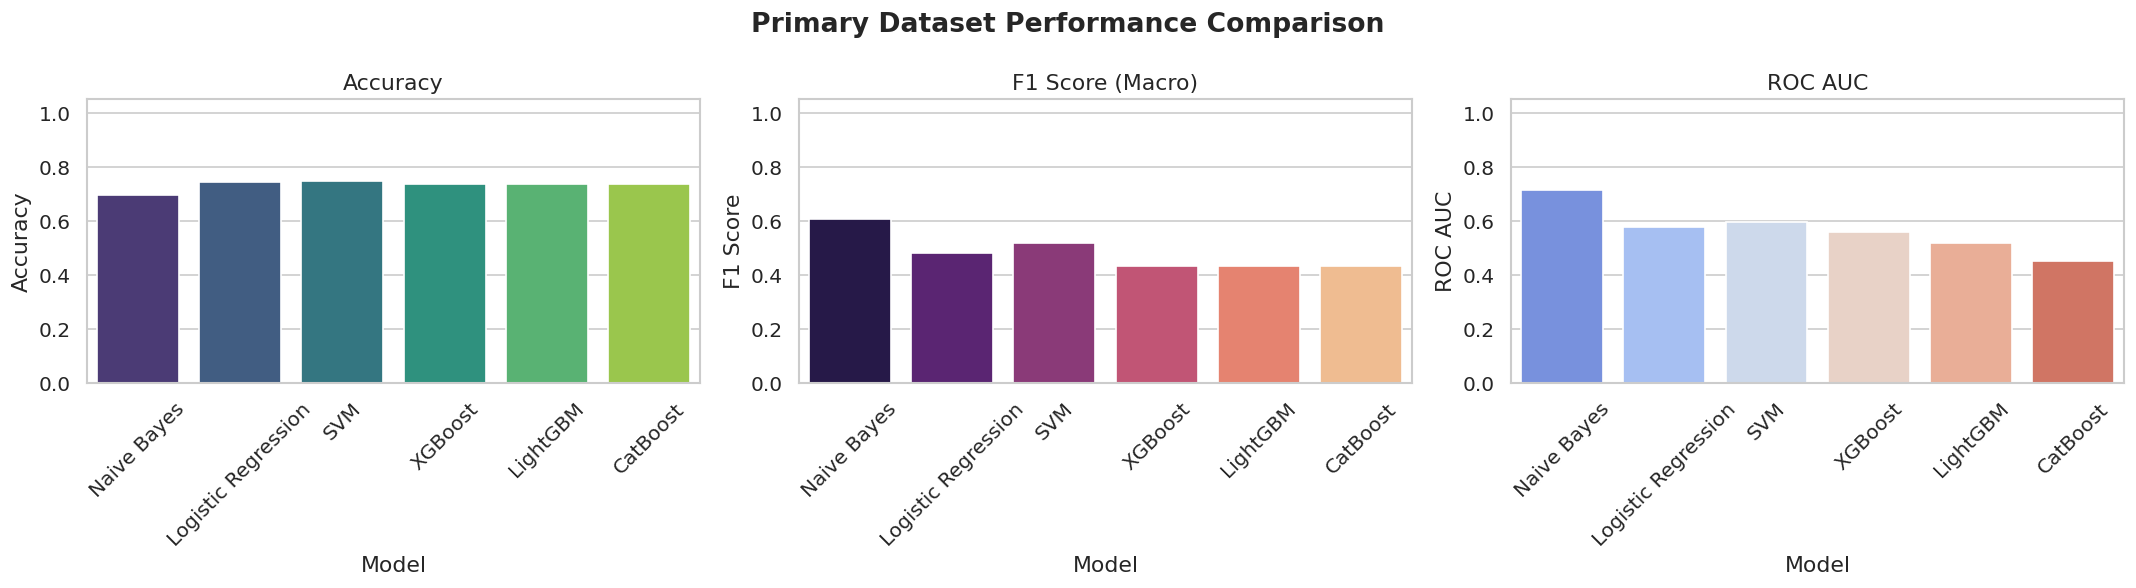


🌍 2. CROSS-DATASET EVALUATION (GENERALIZATION)
Evaluating models on PubHealth dataset...
Evaluating models on FakeHealth dataset...
Evaluating models on CoAID dataset...


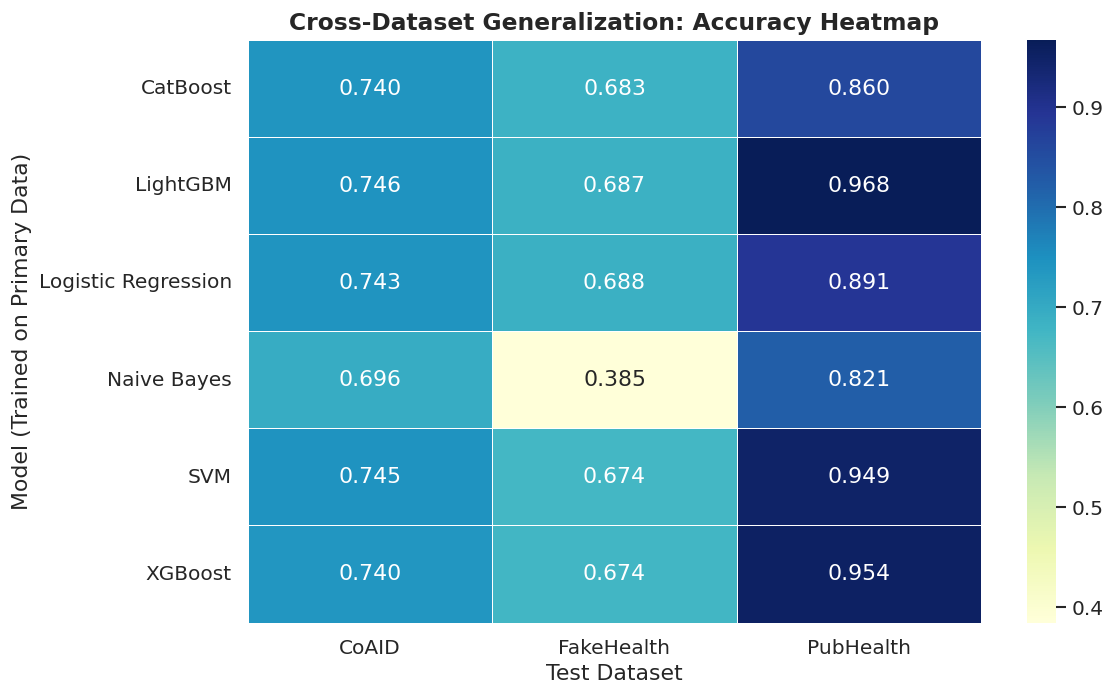


🧠 3. EXPLAINABLE AI (XAI)

--- 3A. Global Feature Importance (Top TF-IDF Words) ---

[Logistic Regression] Top words driving predictions:
  ➡️ REAL: said, health, wednesday, tuesday, job, monday, thursday, week, last, good job
  ➡️ FAKE: claim, news, rumor, however, fact, mention, post, true, doesnt, release

--- 3B. Local Prediction Explanation with LIME ---
Generating LIME explanation using Naive Bayes...


NameError: name 'df_test' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from lime.lime_text import LimeTextExplainer

# ------------------------------------------------------------------------------
# ☠ VARIABLE ASSIGNMENT (Update these with your actual model variables!)
# ------------------------------------------------------------------------------
# 1. Create a dictionary of your trained models.
trained_models = TRAINED_MODELS['PubHealth']

# 2. Make sure these other variables are also correctly pointed to your data
vectorizer = tfidf  
X_test_raw = splits['X_test']
X_test_tfidf = splits['X_test']
y_test = splits['y_test']



# ------------------------------------------------------------------------------
# 1. MODEL COMPARISON VISUALIZATIONS
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("🚀 1. GENERATING MODEL COMPARISON VISUALIZATIONS")
print("="*80)

ml_metrics = []

# Evaluate all models on the primary test set
for name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)

    # Safely get probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_tfidf)
        # Normalize decision function to 0-1 range for AUC
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)
    else:
        y_prob = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_prob)

    ml_metrics.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1, 'ROC AUC': auc})

df_metrics = pd.DataFrame(ml_metrics).set_index('Model')

# Plotting the metrics side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Primary Dataset Performance Comparison', fontsize=16, fontweight='bold')

sns.barplot(x=df_metrics.index, y=df_metrics['Accuracy'], ax=axes[0], palette='viridis')
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=df_metrics.index, y=df_metrics['F1 Score'], ax=axes[1], palette='magma')
axes[1].set_title('F1 Score (Macro)')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x=df_metrics.index, y=df_metrics['ROC AUC'], ax=axes[2], palette='coolwarm')
axes[2].set_title('ROC AUC')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. CROSS-DATASET EVALUATION
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("🌍 2. CROSS-DATASET EVALUATION (GENERALIZATION)")
print("="*80)

cross_eval_results = []

# Iterate through every standardized dataset
for ds_name, df in DATASETS.items():
    print(f"Evaluating models on {ds_name} dataset...")

    # Extract text and labels using standard column names from your notebook
    text_data = df['combined_text']
    y_true = df['label_binary']

    # Vectorize using the PRE-FITTED primary vectorizer
    X_val_tfidf = vectorizer.transform(df['text_classical'])

    for model_name, model in trained_models.items(): # Use trained models from PubHealth for cross-evaluation
        y_pred = model.predict(X_val_tfidf)
        acc = accuracy_score(y_true, y_pred)

        cross_eval_results.append({
            'Test Dataset': ds_name,
            'Model': model_name,
            'Accuracy': acc
        })

df_cross = pd.DataFrame(cross_eval_results)

# Create a Heatmap for Cross-Dataset Accuracy
pivot_acc = df_cross.pivot(index="Model", columns="Test Dataset", values="Accuracy")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_acc, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title("Cross-Dataset Generalization: Accuracy Heatmap", fontsize=14, fontweight='bold')
plt.ylabel("Model (Trained on Primary Data)")
plt.xlabel("Test Dataset")
plt.tight_layout()
plt.show()

[Naive Bayes] Top words driving predictions:
  ➡️ REAL: said
  ➡️ FAKE: Clinton, Hillary, Gingrich, personhood, as, shall, causality, libertarian, Prince
------------------------------------------------------------


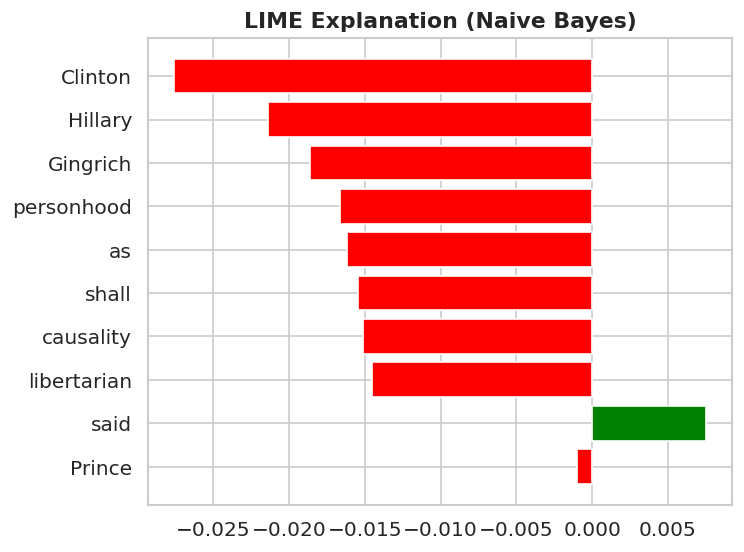

[Logistic Regression] Top words driving predictions:
  ➡️ REAL: said, Department
  ➡️ FAKE: Clinton, post, claim, Hillary, mention, 2013, truth, professor
------------------------------------------------------------


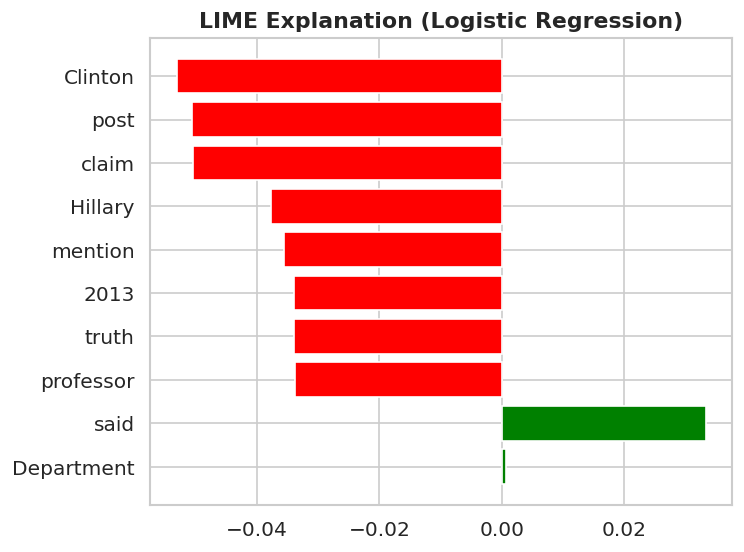

[SVM] Top words driving predictions:
  ➡️ REAL: said, clearly
  ➡️ FAKE: Clinton, claim, professor, post, would, mention, Hillary, truth
------------------------------------------------------------


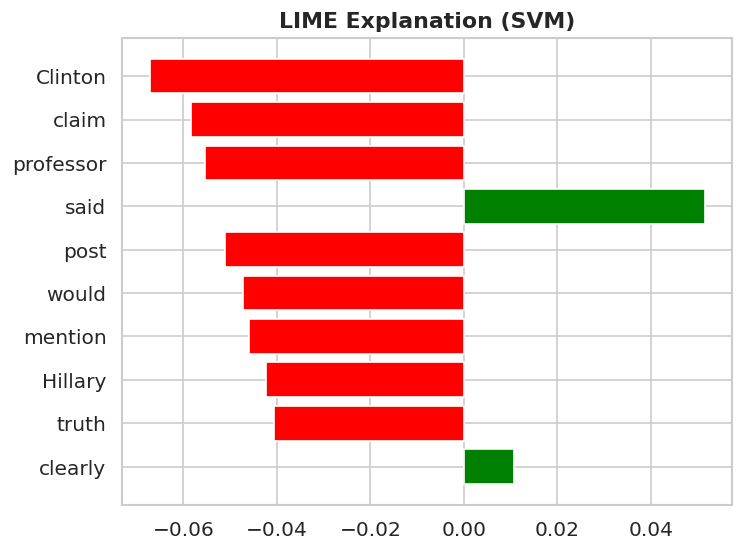

[XGBoost] Top words driving predictions:
  ➡️ REAL: said
  ➡️ FAKE: claim, truth, post, mention, ruling, Article, thus, Clinton, clearly
------------------------------------------------------------


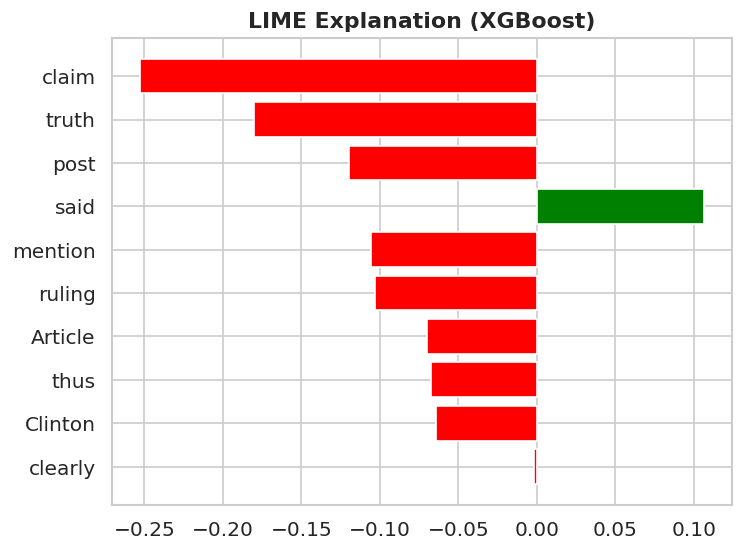

[LightGBM] Top words driving predictions:
  ➡️ REAL: said
  ➡️ FAKE: claim, truth, mention, Clinton, actual, post, Hillary, know, clearly
------------------------------------------------------------


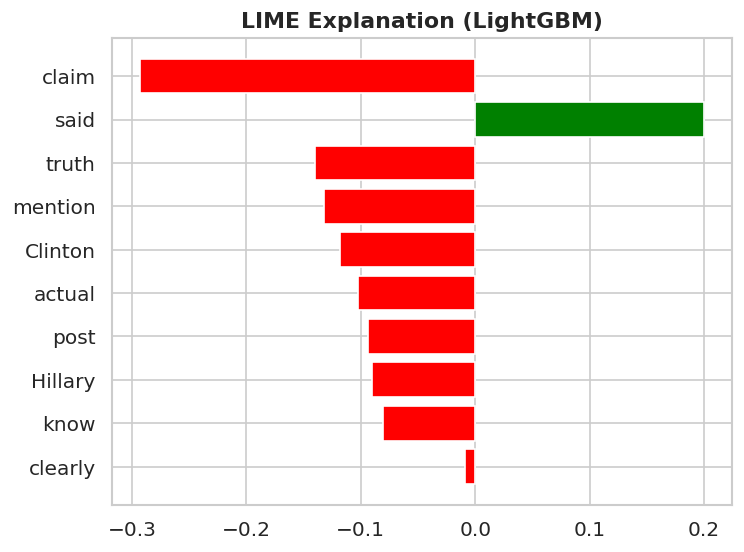

[CatBoost] Top words driving predictions:
  ➡️ REAL: said, health
  ➡️ FAKE: claim, truth, post, mention, Article, actual, assertion, either
------------------------------------------------------------


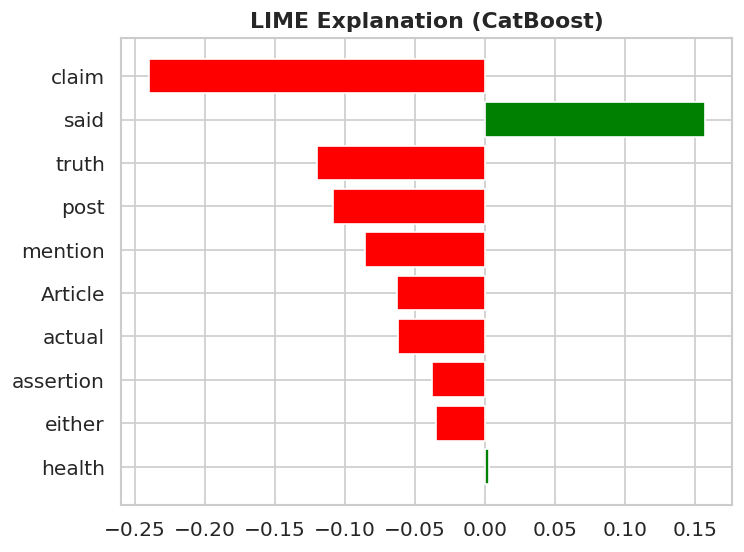

In [ ]:
# ============================================================
# EXPLAINABLE AI --- LIME Explanation––(All Models)
# ============================================================

# 1. Grab a raw text string safely from your standardized DataFrame
sample_idx = 0
sample_text = df_pub['combined_text'].iloc[sample_idx]

# 2. Loop through every trained model in your dictionary
for model_name, model_to_explain in trained_models.items():

    # Create a wrapper prediction function for the current model
    def lime_predict_proba(texts, current_model=model_to_explain):
        texts_vectorized = vectorizer.transform(texts)
        return current_model.predict_proba(texts_vectorized)

    # Generate LIME Explanation
    explainer = LimeTextExplainer(class_names=["FAKE", "REAL"])
    exp = explainer.explain_instance(
        sample_text,
        lime_predict_proba,
        num_features=10
    )

    # Extract and format the features by direction (REAL vs FAKE)
    real_words = []
    fake_words = []

    for feature, weight in exp.as_list():
        if weight > 0:
            real_words.append(feature)
        else:
            fake_words.append(feature) 

    # Print in the requested format for each model
    print(f"[{model_name}] Top words driving predictions:")
    print(f"  ➡️ REAL: {', '.join(real_words)}")
    print(f"  ➡️ FAKE: {', '.join(fake_words)}")
    print("-" * 60)

# Optional: Display visual plot if desired
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation ({model_name})", fontweight='bold')
    plt.tight_layout()
    plt.show()